In [1]:
import os
import pandas as pd
from PIL import Image

DATA_DIR = "data/dataset"

data = []

for split in ["train", "test"]:
    split_dir = os.path.join(DATA_DIR, split)

    for label in os.listdir(split_dir):
        label_dir = os.path.join(split_dir, label)

        if not os.path.isdir(label_dir):
            continue

        for filename in os.listdir(label_dir):
            filepath = os.path.join(label_dir, filename)

            try:
                img = Image.open(filepath)

                data.append({
                    "filepath": filepath,
                    "label": label,
                    "split": split,
                    "width": img.width,
                    "height": img.height
                })

                img.close()

            except:
                pass

df = pd.DataFrame(data)

print(df.head())
print(df.shape)
print(df["label"].value_counts())

                                            filepath        label  split  \
0  data/dataset/train/freshbanana/rotated_by_15_S...  freshbanana  train   
1  data/dataset/train/freshbanana/rotated_by_60_S...  freshbanana  train   
2  data/dataset/train/freshbanana/rotated_by_30_S...  freshbanana  train   
3  data/dataset/train/freshbanana/vertical_flip_S...  freshbanana  train   
4  data/dataset/train/freshbanana/translation_Scr...  freshbanana  train   

   width  height  
0    554     454  
1    608     402  
2    840     440  
3    420     332  
4    538     372  
(19956, 5)
label
rottenapples     2943
rottenbanana     2754
unripe banana    2497
unripe apple     2305
freshapples      2088
rottenoranges    1998
freshbanana      1962
freshoranges     1854
unripe orange    1555
Name: count, dtype: int64


In [5]:
df['split'].value_counts()

split
train    16217
test      3739
Name: count, dtype: int64

#### Average Image Dimensions Inspection

In [ ]:
df["width"].describe()

count    19956.000000
mean       278.027009
std        126.737850
min         40.000000
25%        140.000000
50%        316.000000
75%        388.000000
max        518.000000
Name: height, dtype: float64

In [3]:
df["height"].describe()

count    19956.000000
mean       278.027009
std        126.737850
min         40.000000
25%        140.000000
50%        316.000000
75%        388.000000
max        518.000000
Name: height, dtype: float64

In [6]:
pd.crosstab(df["label"], df["split"])

split,test,train
label,,
freshapples,395,1693
freshbanana,381,1581
freshoranges,388,1466
rottenapples,601,2342
rottenbanana,530,2224
rottenoranges,403,1595
unripe apple,371,1934
unripe banana,400,2097
unripe orange,270,1285


#### Average Aspect Ratio

In [4]:
df["aspect_ratio"] = df["width"] / df["height"]

df["aspect_ratio"].describe()

count    19956.000000
mean         1.225050
std          0.322268
min          0.350000
25%          1.010582
50%          1.160377
75%          1.446237
max          4.050000
Name: aspect_ratio, dtype: float64

#### Image Size Outliers

Outliers in Aspect Ratio

In [12]:
df["aspect_ratio"] = df["width"] / df["height"]

Q1 = df["aspect_ratio"].quantile(0.25)
Q3 = df["aspect_ratio"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df["aspect_ratio"] < Q1 - 1.5 * IQR) |
    (df["aspect_ratio"] > Q3 + 1.5 * IQR)
]

print(outliers)

                                                filepath          label  \
32     data/dataset/train/freshbanana/saltandpepper_S...    freshbanana   
43     data/dataset/train/freshbanana/rotated_by_60_S...    freshbanana   
55     data/dataset/train/freshbanana/Screen Shot 201...    freshbanana   
110    data/dataset/train/freshbanana/rotated_by_15_S...    freshbanana   
190    data/dataset/train/freshbanana/rotated_by_75_S...    freshbanana   
...                                                  ...            ...   
19661             data/dataset/test/unripe banana/90.jpg  unripe banana   
19681            data/dataset/test/unripe banana/147.jpg  unripe banana   
19750             data/dataset/test/unripe orange/14.jpg  unripe orange   
19771             data/dataset/test/unripe orange/16.jpg  unripe orange   
19816             data/dataset/test/unripe orange/22.jpg  unripe orange   

       split  width  height  aspect_ratio  
32     train    786     300      2.620000  
43     trai

Text(0.5, 1.0, 'Distribution of Image Aspect Ratios')

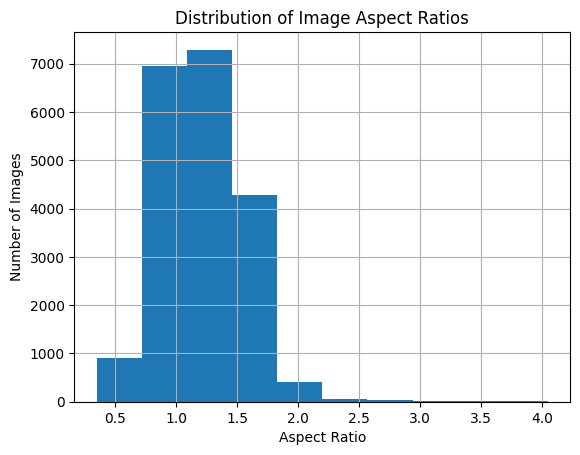

In [14]:
ax = df["aspect_ratio"].hist()

ax.set_xlabel("Aspect Ratio")
ax.set_ylabel("Number of Images")
ax.set_title("Distribution of Image Aspect Ratios")